# Decision Trees

## 1. O que são Decision Trees?

De acordo com a IBM, decision trees são algoritmos de aprendizagem supervisionadas não paramétricas que são utilizadas tanto para tarefas de classificação como também para de regressão. Têm uma hierarquia, estrutura em árvore, que consiste num nó raíz, ramos, nós internos e nós folhas. 

## 2. Diferenças entre tarefas de classificação e regressão

A diferença entre tarefas de classificação e de regressão é que a de classificação têm como objetivo atribuir entradas para especificar categorias pré-definidas, para que as saídas sejam algo qualitativo. Pelo outro lado, as tarefas de regressão têm como objetivo prever algo contínuo (quantidade numérica), para que as saídas sejam números com valores reais, que podem cair em qualquer lugar, ao longo de uma escala/gráfico. Outra diferença entre estas tarefas é que os gráficos são, obviamente diferentes, onde o gráfico de classificação é distinto e os de regressão são lineares.


## 3. Diagramas de Decision Trees

Um diagrama de decision trees é distribuído por diferentes blocos, que contêm diferentes hierarquias, onde:
- O primeiro bloco é um nó raíz, onde é feita uma pergunta;
- De seguida, vão existir blocos de nós internos, onde é feito o desmembramento entre, por exemplo: "Sim/Não";
- Após desmembrar, vão ser criados novos ramos, que passam a ser uma espécie de sub-nós internos;
- E por fim, para obter as respostas, são usados os blocos de nós folhas.

## 4. Tarefa de Classificação 

Foi criada uma Decision Tree para classificar a espécie da IRIS a partir das 4 características e é mostrada a árvore e a matriz de confusão.
- A árvore de decisão é um modelo de classificação que utiliza uma estrutura hierárquica para tomar decisões com base em perguntas sobre as características dos dados. No caso do IRIS Dataset, a árvore de decisão é treinada para classificar as flores em três espécies diferentes (Setosa, Versicolor e Virginica) com base nas quatro características (comprimento da sépala, largura da sépala, comprimento da pétala e largura da pétala). A árvore é construída dividindo os dados em nós internos com base nas características mais informativas, até chegar aos nós folhas que representam as classes finais;
- A matriz de confusão é uma ferramenta utilizada para avaliar o desempenho do modelo de classificação, mostrando a contagem de verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos. Ela ajuda a entender a precisão do modelo e identificar possíveis erros na classificação.

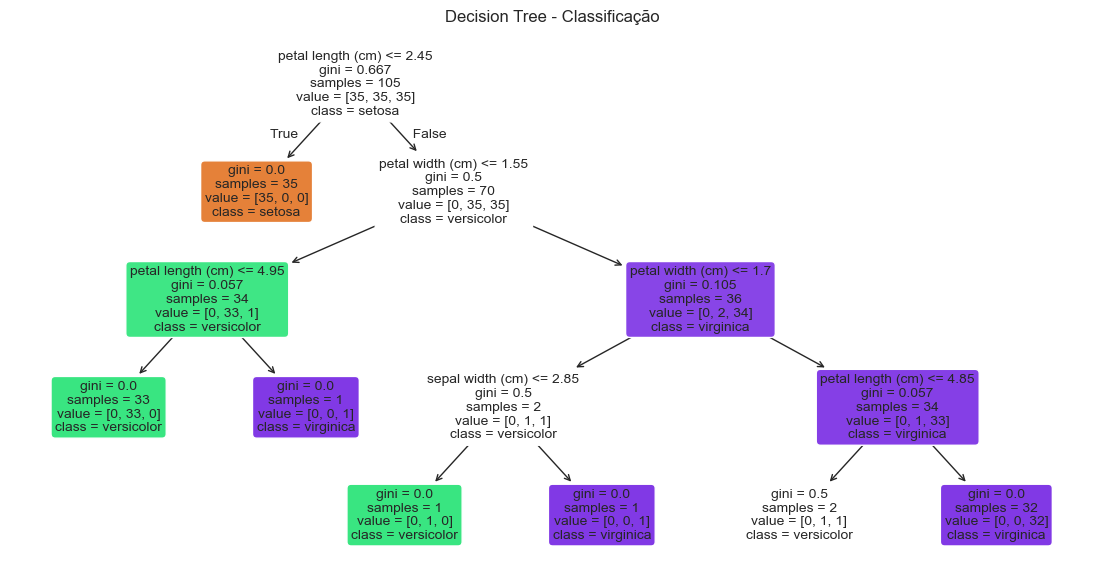

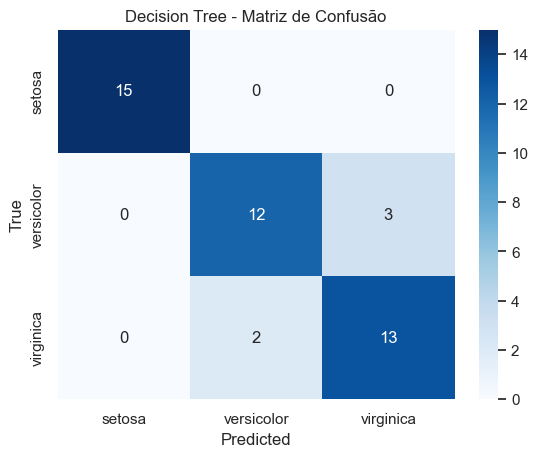

In [59]:
# Tarefa de Classificação usando o ficheiro IrisDataset.csv 
import pandas as pd # Importa a biblioteca pandas para manipulação de dados
import numpy as np # Importa a biblioteca numpy para operações numéricas
import matplotlib.pyplot as plt # Importa a biblioteca matplotlib para visualização de dados
import seaborn as sns # Importa a biblioteca seaborn para visualização de dados

plt.figure(figsize=(14,7)) # Define o tamanho da figura para o gráfico da árvore de decisão
plot_tree(clf, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=10) # Plota a árvore de decisão com as características, classes, preenchimento de cores, nós arredondados e fonte de tamanho 10
plt.title('Decision Tree - Classificação') # Define o título do gráfico da árvore de decisão
plt.show() # Exibe o gráfico da árvore de decisão

cm = confusion_matrix(y_test, y_pred) # Calcula a matriz de confusão usando os rótulos verdadeiros (y_test) e as previsões do modelo (y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names) # Plota a matriz de confusão como um mapa de calor, com anotações dos valores, formato inteiro, colormap azul e rótulos dos eixos usando os nomes das classes
plt.xlabel('Predicted') # Define o rótulo do eixo x como 'Predicted'
plt.ylabel('True') # Define o rótulo do eixo y como 'True'
plt.title('Decision Tree - Matriz de Confusão') # Define o título do gráfico da matriz de confusão
plt.show() # Exibe o gráfico da matriz de confusão

## 5. Tarefa de Regressão 

Foi usada a  DecisionTreeRegressor para prever o comprimento da pétala (`petal length (cm)`) a partir das outras características.

- A DecisionTreeRegressor é um modelo de regressão que utiliza uma estrutura hierárquica semelhante à árvore de decisão, mas é projetada para prever valores contínuos. No caso do IRIS Dataset, o modelo é treinado para prever o comprimento da pétala com base nas outras características (comprimento da sépala, largura da sépala e largura da pétala). O modelo é construído dividindo os dados em nós internos com base nas características mais informativas, até chegar aos nós folhas que representam as previsões finais para o comprimento da pétala.
- O segundo gráfico pode ser intrepertado como uma comparação entre os valores reais e os valores previstos pelo modelo de regressão. Ele mostra a relação entre as características usadas para prever o comprimento da pétala e os valores reais e previstos, permitindo avaliar a precisão do modelo e identificar possíveis padrões ou discrepâncias nos dados.

MSE: 0.0778  R2: 0.9769


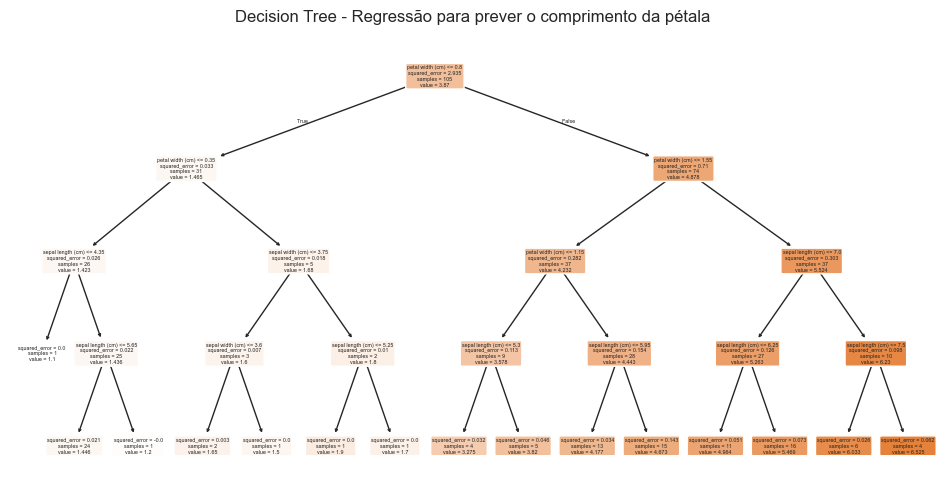

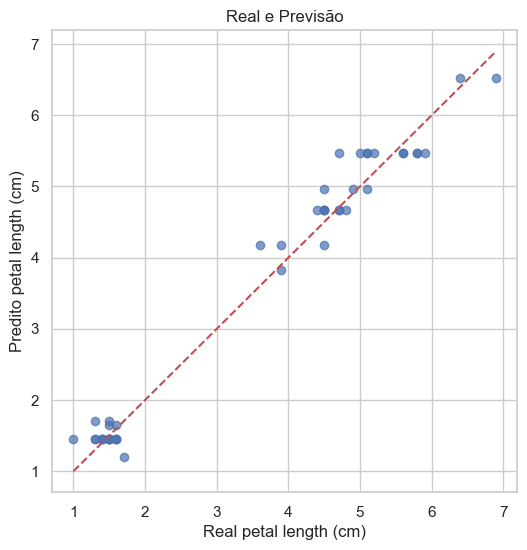

In [ ]:
# Tarefa de Regressão usando o ficheiro IrisDataset.csv
features = ['sepal length (cm)','sepal width (cm)','petal width (cm)'] # Define as características a serem usadas para prever o comprimento da pétala, excluindo a própria característica de comprimento da pétala
Xr = df[features].values # Seleciona as colunas de características para regressão
yr = df['petal length (cm)'].values # Seleciona a coluna de rótulos para regressão (comprimento da pétala)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=42) # Divide os dados de regressão em conjuntos de treino e teste (70% treino, 30% teste) com uma semente aleatória para reprodutibilidade
reg = DecisionTreeRegressor(max_depth=4, random_state=42) # Cria o regressor de árvore de decisão com profundidade máxima de 4 e semente aleatória para reprodutibilidade
reg.fit(Xr_train, yr_train) # Treina o modelo de regressão de árvore de decisão com os dados de treino
yr_pred = reg.predict(Xr_test) # Faz previsões com o modelo de regressão treinado usando os dados de teste

# Métricas
mse = mean_squared_error(yr_test, yr_pred) # Calcula o erro quadrático médio comparando os valores reais (yr_test) com os valores previstos (yr_pred)
r2 = r2_score(yr_test, yr_pred) # Calcula o coeficiente de determinação (R²) comparando os valores reais (yr_test) com os valores previstos (yr_pred)
print(f'MSE: {mse:.4f}  R2: {r2:.4f}') # Imprime o erro quadrático médio e o coeficiente de determinação com 4 casas decimais

# Plot árvore de regressão
plt.figure(figsize=(12,6)) # Define o tamanho da figura para o gráfico da árvore de regressão
plot_tree(reg, feature_names=features, filled=True, rounded=True) # Plota a árvore de regressão com as características, preenchimento de cores e nós arredondados
plt.title('Decision Tree - Regressão para prever o comprimento da pétala ') # Define o título do gráfico da árvore de regressão
plt.show() # Exibe o gráfico da árvore de regressão

# Scatter: valores reais vs previstos
plt.figure(figsize=(6,6)) # Define o tamanho da figura para o gráfico de dispersão dos valores reais vs previstos
plt.scatter(yr_test, yr_pred, alpha=0.7) # Cria um gráfico de dispersão comparando os valores reais (yr_test) com os valores previstos (yr_pred) usando pontos com transparência (alpha=0.7)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--') # Adiciona uma linha de referência (linha vermelha tracejada) para indicar onde os valores reais seriam iguais aos valores previstos
plt.xlabel('Real petal length (cm)') # Define o rótulo do eixo x para o gráfico de dispersão
plt.ylabel('Predito petal length (cm)') # Define o rótulo do eixo y para o gráfico de dispersão
plt.title('Real e Previsão') # Define o título do gráfico de dispersão dos valores reais vs previstos
plt.show() # Exibe o gráfico de dispersão dos valores reais vs previstos

# IRIS Dataset

## 1. Autores e a origem do IRIS Dataset

- Sir Ronald A. Fisher: Um estatístico e biólogo britânico, chamado de "o pai da estatística moderna, ele criou ferramentas que usamos até hoje, como a ANOVA (Análise de Variância) e o conceito de valor-p;
- Edgar Anderson: Um botânico americano que recolheu os dados nas montanhas de Gaspé Peninsula, no Canadá, para quantificar a variação morfológica das flores.

Observação: O IRIS Dataset foi publicado em 1936, no artigo "The Use of Multiple Measurements in Taxonomic Problems" por Ronald A. Fisher, onde ele utilizou os dados recolhidos por Edgar Anderson para demonstrar a aplicação de técnicas estatísticas na classificação de espécies de flores.

## 2. O que é o IRIS Dataset?

De acordo com o GeekForges, o IRIS Dataset é um conjunto de dados usados em machine learning, que têm como objetivo facilitar na fase de classificação de algoritmos. A IRIS Dataset consiste  em 150 amostras de flores iris a partir de 3 espécies diferentes, sendo estas: Setosa, Versicolor e Virginica. Cada amostra apresenta quatro características: comprimento da sépala, largura da sépala, comprimento da pétala e a largura da pétala (em cm).  Este conjunto de dados é particularmente popular, devido à sua simplicidade e a forma clara de separação de diferentes espécies, de acordo com as  características referidas anteriormente.
Cada variável representa as bem-ditas espécies:
- Iris Setosa - Caracterízada pelo seu pequeno tamanho e com características distintas nas dimensões das sépalas e pétalas;
- Iris Versicolor - Moderada em tamanho, com características semelhantes à Iris Setosa e à Iris Virginica;
- Iris Virginica - Geralmente mais largas em tamanho, com diferenças notáveis nas sépalas e pétalas, em relação às outras duas.

Esta dataset, pode ser muito utilizada em frameworks populares de machine learning, tais como: scikit-learn, TensorFlow e PyTorch. 
Concluíndo, esta dataset permite comparar dados e facilitar na visualização dos mesmos, isto para quem é iniciante na área de machine learning. 

Neste caso, foi criada uma tabela de comparação entre as espécies, onde se pode observar as diferenças entre as características das flores.

In [ ]:
import pandas as pd # Importa a biblioteca pandas para manipulação de dados
import numpy as np # Importa a biblioteca numpy para operações numéricas

csv_path = './IrisDataset.csv' # Caminho para o arquivo CSV contendo o dataset Iris
df = pd.read_csv(csv_path) # Lê o arquivo CSV e armazena os dados em um DataFrame do pandas
df.sample(10) # Exibe uma amostra aleatória de 10 linhas do DataFrame para visualização dos dados

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
22,4.6,3.6,1.0,0.2,setosa
37,4.9,3.6,1.4,0.1,setosa
89,5.5,2.5,4.0,1.3,versicolor
49,5.0,3.3,1.4,0.2,setosa
87,6.3,2.3,4.4,1.3,versicolor
35,5.0,3.2,1.2,0.2,setosa
27,5.2,3.5,1.5,0.2,setosa
20,5.4,3.4,1.7,0.2,setosa
118,7.7,2.6,6.9,2.3,virginica
15,5.7,4.4,1.5,0.4,setosa


## 3. Visualizações exploratórias a partir dos dados do IRIS Dataset

Foi gerado um pairplot para visualizar as relações entre as características do IRIS Dataset, colorido por espécie. O pairplot é uma ferramenta de visualização que mostra as distribuições univariadas e as relações bivariadas entre as características, permitindo identificar padrões e diferenças entre as espécies.

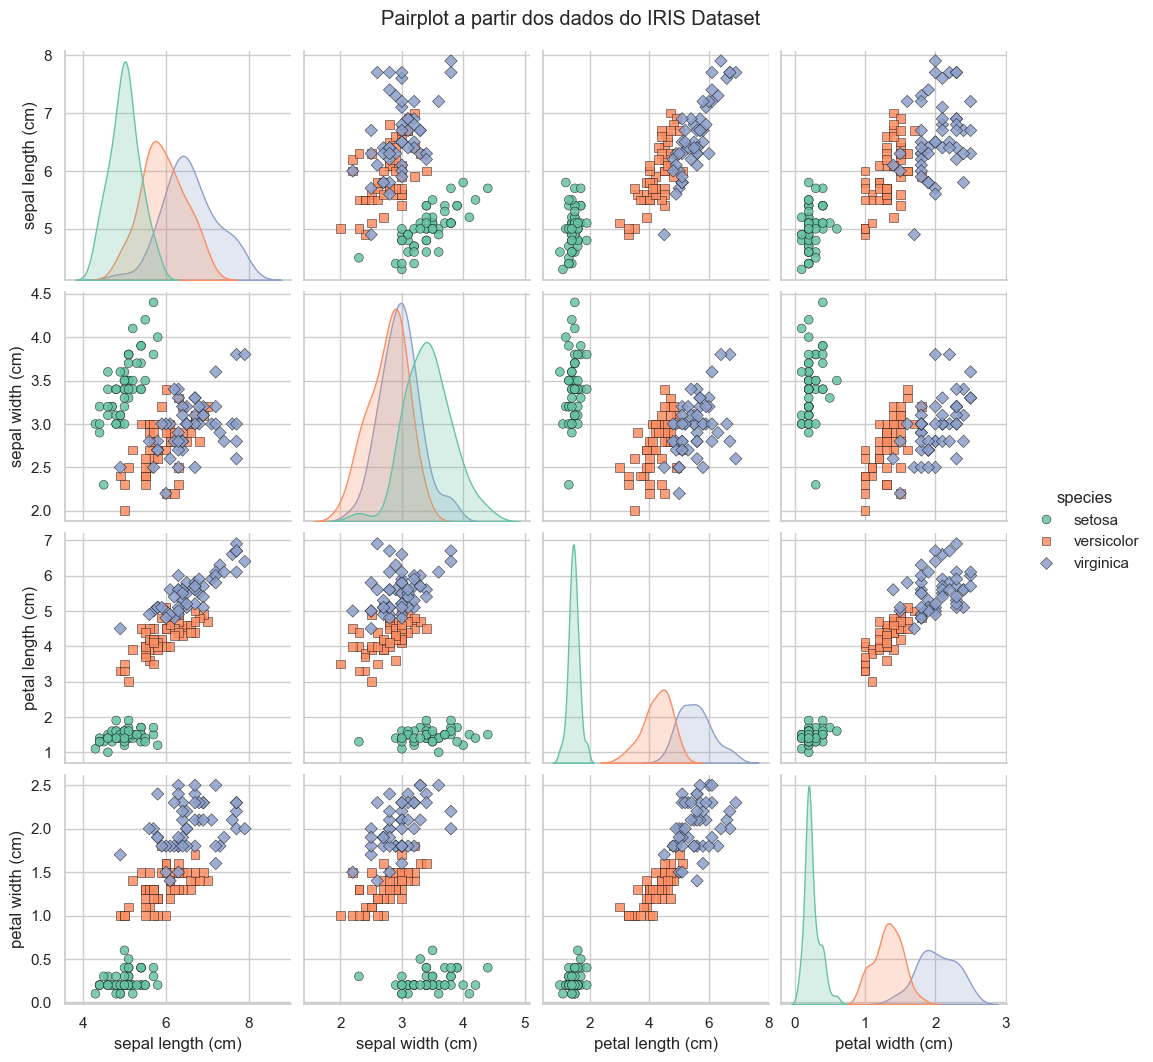

In [71]:
import seaborn as sns # Importa a biblioteca seaborn para visualização de dados
import matplotlib.pyplot as plt # Importa a biblioteca matplotlib para visualização de dados
pp = sns.pairplot(df, vars=iris['feature_names'], hue='species', diag_kind='kde', kind='scatter', corner=False, height=2.6, plot_kws={'s':40,'edgecolor':'k','linewidth':0.4,'alpha':0.85}, palette='Set2', markers=['o','s','D']) # Cria um pairplot usando o seaborn para visualizar as relações entre as características do dataset, colorindo os pontos de acordo com a espécie, usando gráficos de dispersão e densidade, e personalizando a aparência dos pontos e do gráfico
pp.fig.suptitle('Pairplot a partir dos dados do IRIS Dataset', y=1.02) # Define o título do pairplot e ajusta a posição vertical do título para evitar sobreposição com os subplots
plt.show() # Exibe o pairplot criado para visualizar as relações entre as características do dataset Iris, colorindo os pontos de acordo com a espécie e usando gráficos de dispersão e densidade para melhor compreensão dos dados.

# Conclusão

Resumindo, as Decision Trees são modelos de aprendizagem supervisionada que podem ser usados tanto para classificação como para regressão. A diferença entre estas tarefas é que a classificação tem como objetivo atribuir entradas para categorias pré-definidas, enquanto a regressão tem como objetivo prever algo contínuo. Os diagramas de Decision Trees consistem em um nó raíz, ramos, nós internos e nós folhas. No caso do IRIS Dataset, foi criada uma árvore de decisão para classificar as espécies das flores com base nas suas características, e também foi usada uma árvore de decisão para prever o comprimento da pétala. O IRIS Dataset é um conjunto de dados amplamente utilizado em machine learning, contendo amostras de flores iris de três espécies diferentes, com quatro características cada. Visualizações exploratórias, como o pairplot, ajudam a entender as relações entre as características e as diferenças entre as espécies.
